In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
from config import SimConfig
from src.data_processing import load_and_cache_entire_fleet
from src.utils.evaluation import VoyageBenchmarker

from src.plants.fc_only_plant import FuelCellOnlyPlant
from src.solvers.sdp_baseline import BaselineSDPSolver
from src.controllers.constant import ConstantControl
from src.controllers.threshold import ThresholdControl
from src.controllers.stochastic import StochasticControl
from src.plotting import plot_dynamic_history, plot_cost_comparison, plot_benchmarker_results

config = SimConfig()
fleet_data = load_and_cache_entire_fleet(config)

# Initialize benchmarker, excluding corrupted or unrepresentative data
exclude_days = [] # Adjust this list as needed based on data quality
benchmarker = VoyageBenchmarker(fleet_data, config, exclude_days)

Beginning memory staging of all 14 fleet files into RAM...
 -> Day 01 successfully cached in RAM.
 -> Day 02 successfully cached in RAM.
 -> Day 03 successfully cached in RAM.
 -> Day 04 successfully cached in RAM.
 -> Day 05 successfully cached in RAM.
 -> Day 06 successfully cached in RAM.
 -> Day 07 successfully cached in RAM.
 -> Day 08 successfully cached in RAM.
 -> Day 09 successfully cached in RAM.
 -> Day 10 successfully cached in RAM.
 -> Day 11 successfully cached in RAM.
 -> Day 12 successfully cached in RAM.
 -> Day 13 successfully cached in RAM.
 -> Day 14 successfully cached in RAM.

All 14 operational days securely held in RAM. Disk I/O locked.


In [3]:
# We wrap instantiations in functions so the benchmarker can spin up fresh 
# plants for every cross-validation day, preventing state-bleeding.

def build_constant(cfg, mc, horizon):
    return ConstantControl(cfg), FuelCellOnlyPlant(cfg)

def build_threshold(cfg, mc, horizon):
    return ThresholdControl(cfg, horizon, sigma=0.5), FuelCellOnlyPlant(cfg)

def build_sdp(cfg, mc, horizon):
    solver = BaselineSDPSolver(cfg, mc)
    policy = solver.compute_policy_matrix(horizon)
    ctrl = StochasticControl(mc['levels'], cfg.n_vals, policy)
    return ctrl, FuelCellOnlyPlant(cfg)

approaches = {
    "Constant Baseline": build_constant,
    "Threshold Heuristic": build_threshold,
    "Full SDP": build_sdp
}

In [4]:
print("--- APPROACH A: HAND-PICKED EVALUATION ---")
# Manually choose training block and test validation target
train_days = [4, 5, 6, 7, 8, 9, 10]
test_day = 14
df_manual = benchmarker.compare_approaches(approaches, train_days, test_day)
display(df_manual)

--- APPROACH A: HAND-PICKED EVALUATION ---


,Total Cost [€],Operating Cost [€],Switching Cost [€],Transient Cost [€],Battery Cost [€]
Constant Baseline,6066.706261,6066.706261,0.0,0.0,0.0
Threshold Heuristic,5169.623856,4757.123856,412.5,0.0,0.0
Full SDP,4931.485173,4743.985173,187.5,0.0,0.0



--- APPROACH B: LEAVE-ONE-OUT (Full SDP) ---


,Total Cost [€],Operating Cost [€],Switching Cost [€],Transient Cost [€],Battery Cost [€]
Day 1,2460.077673,2216.327673,243.750000,0.0,0.0
Day 2,2406.176139,2162.426139,243.750000,0.0,0.0
Day 3,5510.643297,5266.893297,243.750000,0.0,0.0
Day 4,6157.281023,5988.531023,168.750000,0.0,0.0
Day 5,4983.499373,4814.749373,168.750000,0.0,0.0
Day 6,5080.279636,4892.779636,187.500000,0.0,0.0
Day 7,5181.981987,4975.731987,206.250000,0.0,0.0
Day 8,5073.440147,4904.690147,168.750000,0.0,0.0
Day 9,5800.587316,5613.087316,187.500000,0.0,0.0
Day 10,5541.683733,5354.183733,187.500000,0.0,0.0


,Total Cost [€],Operating Cost [€],Switching Cost [€],Transient Cost [€],Battery Cost [€]
Day 1,2312.390093,2181.140093,131.250000,0.0,0.0
Day 2,2185.514818,2129.264818,56.250000,0.0,0.0
Day 3,5138.063695,5006.813695,131.250000,0.0,0.0
Day 4,6257.228513,5957.228513,300.000000,0.0,0.0
Day 5,4991.808296,4804.308296,187.500000,0.0,0.0
Day 6,5349.768053,4899.768053,450.000000,0.0,0.0
Day 7,5453.350164,4965.850164,487.500000,0.0,0.0
Day 8,5424.975270,4899.975270,525.000000,0.0,0.0
Day 9,5890.743383,5590.743383,300.000000,0.0,0.0
Day 10,5658.109989,5245.609989,412.500000,0.0,0.0


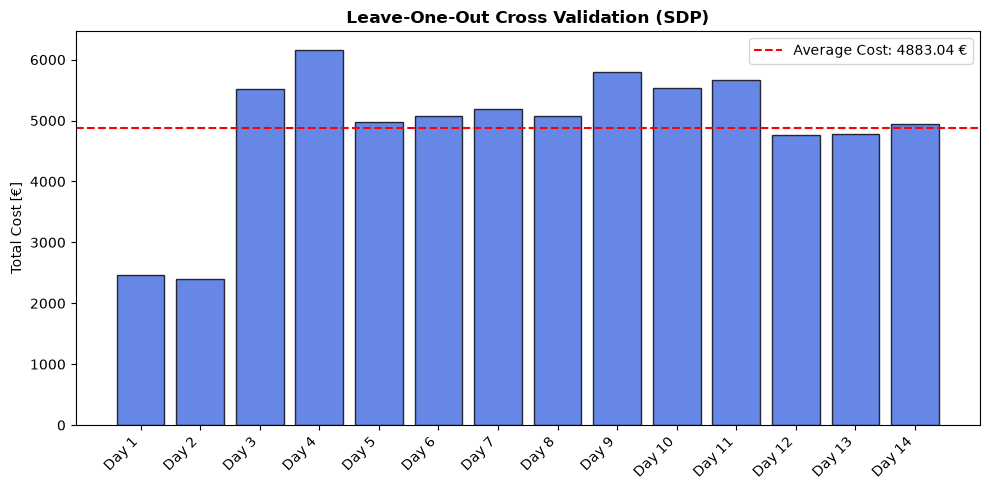

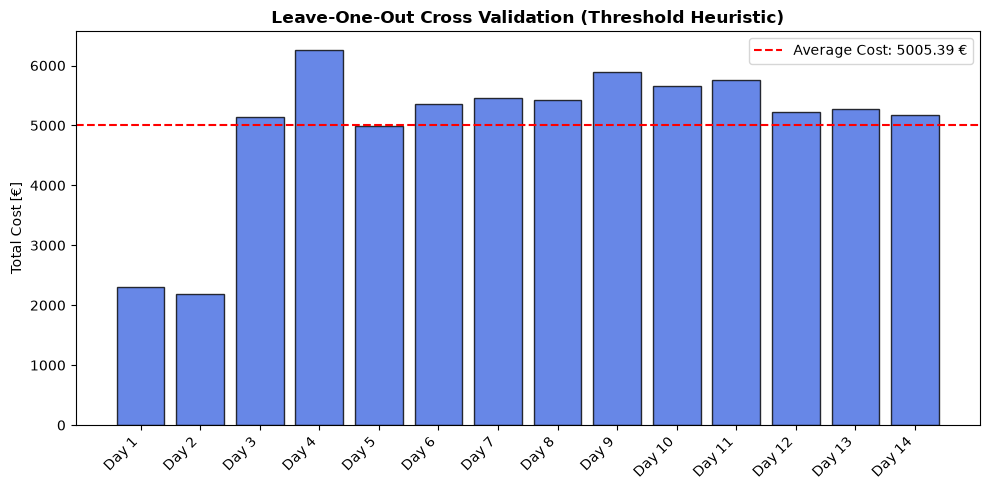

In [5]:
print("\n--- APPROACH B: LEAVE-ONE-OUT (Full SDP) ---")

# Systematically validate against every single viable day in the dataset
df_loo_sdp = benchmarker.run_leave_one_out(approaches["Full SDP"])
display(df_loo_sdp)

df_loo_thresh = benchmarker.run_leave_one_out(approaches["Threshold Heuristic"])
display(df_loo_thresh)


# Visualize the day-to-day volatility
plot_benchmarker_results(df_loo_sdp, title="Leave-One-Out Cross Validation (SDP)", plot_type='bar')
plot_benchmarker_results(df_loo_thresh, title="Leave-One-Out Cross Validation (Threshold Heuristic)", plot_type='bar')


--- APPROACH C: FORWARD CHAINING (Full SDP) ---


,Total Cost [€],Operating Cost [€],Switching Cost [€],Transient Cost [€],Battery Cost [€]
Train 1-1 -> Test 2,2213.306703,2119.556703,93.750000,0.0,0.0
Train 1-2 -> Test 3,6635.769428,6542.019428,93.750000,0.0,0.0
Train 1-3 -> Test 4,6157.281023,5988.531023,168.750000,0.0,0.0
Train 1-4 -> Test 5,5143.362785,4937.112785,206.250000,0.0,0.0
Train 1-5 -> Test 6,5106.613816,4900.363816,206.250000,0.0,0.0
Train 1-6 -> Test 7,5202.153897,4977.153897,225.000000,0.0,0.0
Train 1-7 -> Test 8,5092.501476,4905.001476,187.500000,0.0,0.0
Train 1-8 -> Test 9,5821.295327,5615.045327,206.250000,0.0,0.0
Train 1-9 -> Test 10,5562.028854,5355.778854,206.250000,0.0,0.0
Train 1-10 -> Test 11,5663.237758,5494.487758,168.750000,0.0,0.0


,Total Cost [€],Operating Cost [€],Switching Cost [€],Transient Cost [€],Battery Cost [€]
Train 1-1 -> Test 2,2185.514818,2129.264818,56.250000,0.0,0.0
Train 1-2 -> Test 3,5138.063695,5006.813695,131.250000,0.0,0.0
Train 1-3 -> Test 4,6257.228513,5957.228513,300.000000,0.0,0.0
Train 1-4 -> Test 5,4991.808296,4804.308296,187.500000,0.0,0.0
Train 1-5 -> Test 6,5349.768053,4899.768053,450.000000,0.0,0.0
Train 1-6 -> Test 7,5453.350164,4965.850164,487.500000,0.0,0.0
Train 1-7 -> Test 8,5424.975270,4899.975270,525.000000,0.0,0.0
Train 1-8 -> Test 9,5890.743383,5590.743383,300.000000,0.0,0.0
Train 1-9 -> Test 10,5658.109989,5245.609989,412.500000,0.0,0.0
Train 1-10 -> Test 11,5755.635127,5493.135127,262.500000,0.0,0.0


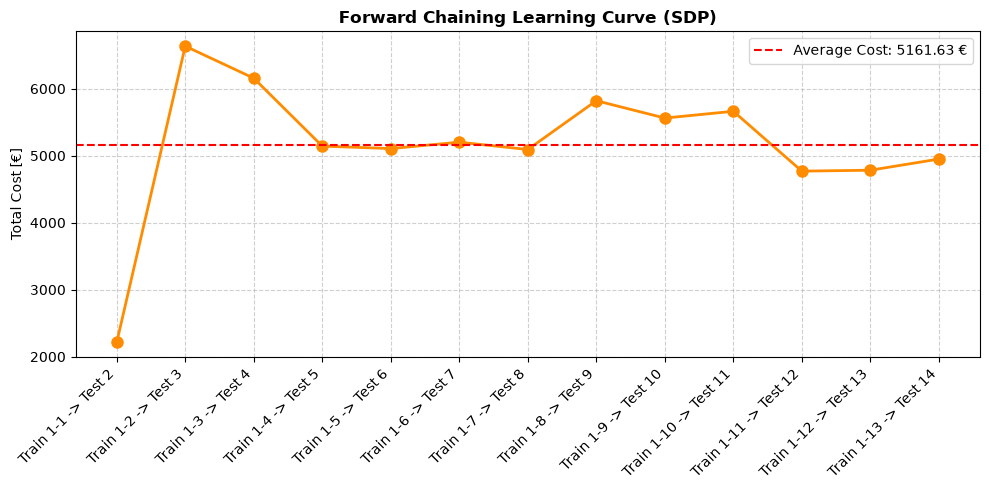

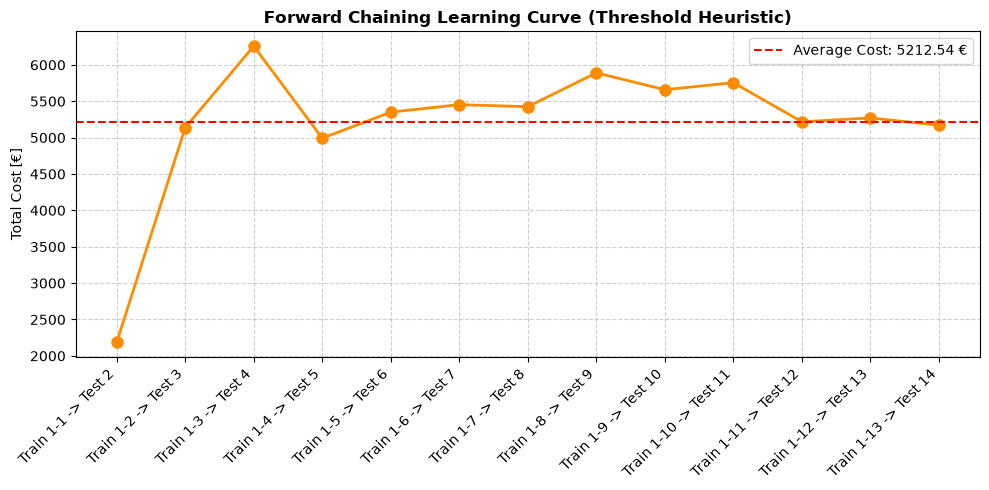

In [7]:

print("\n--- APPROACH C: FORWARD CHAINING (Full SDP) ---")
# Evaluate how the policy improves as the agent gathers chronological data
df_for_sdp = benchmarker.run_forward_chaining(approaches["Full SDP"])
display(df_for_sdp)

df_for_thresh = benchmarker.run_forward_chaining(approaches["Threshold Heuristic"])
display(df_for_thresh)


# Visualize the day-to-day volatility
plot_benchmarker_results(df_for_sdp, title="Forward Chaining Learning Curve (SDP)", plot_type='line')
plot_benchmarker_results(df_for_thresh, title="Forward Chaining Learning Curve (Threshold Heuristic)", plot_type='line')